In [1]:
# Read panel data with merged macro + AQI features.
import pandas as pd

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder

import matplotlib.pyplot as plt

import shap


/Users/deniskaydanov/miniforge3/envs/jhu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1. 

Load the cleaned data and process it for modelling: split into train and test sets.


In [2]:
default_fe_path = Path('../data/default_fe.parquet')
prepay_fe_path = Path('../data/prepay_fe.parquet')

default_fe = pd.read_parquet(default_fe_path)
prepay_fe = pd.read_parquet(prepay_fe_path)

print(f'default_fe shape: {default_fe.shape}')
print(f'prepay_fe shape:  {prepay_fe.shape}')


default_fe shape: (1785162, 47)
prepay_fe shape:  (1785162, 47)


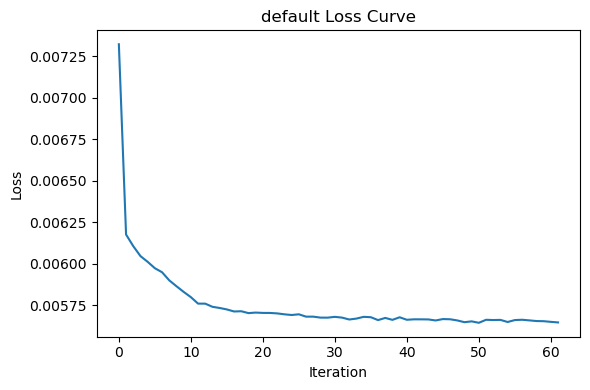

PermutationExplainer explainer: 1001it [00:13, 18.33it/s]                         


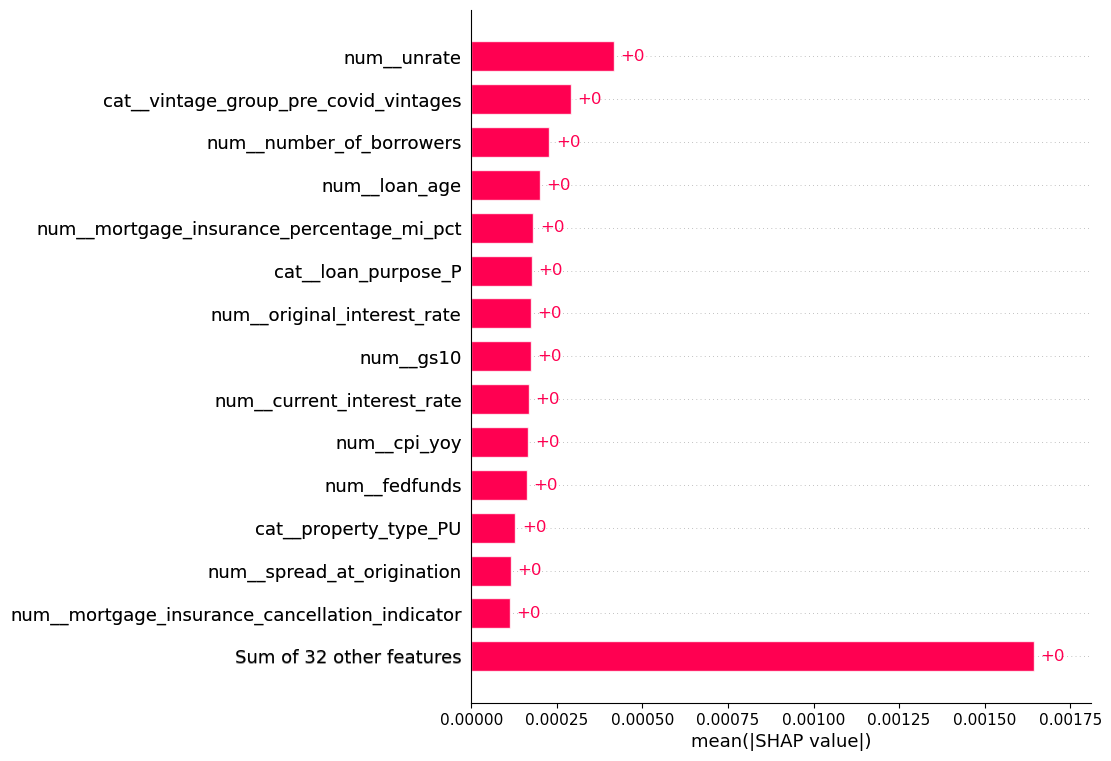

/Users/deniskaydanov/miniforge3/envs/jhu/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


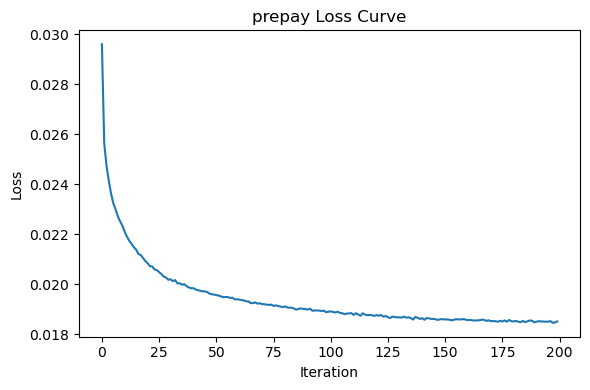

PermutationExplainer explainer: 1001it [00:11, 11.72it/s]                          


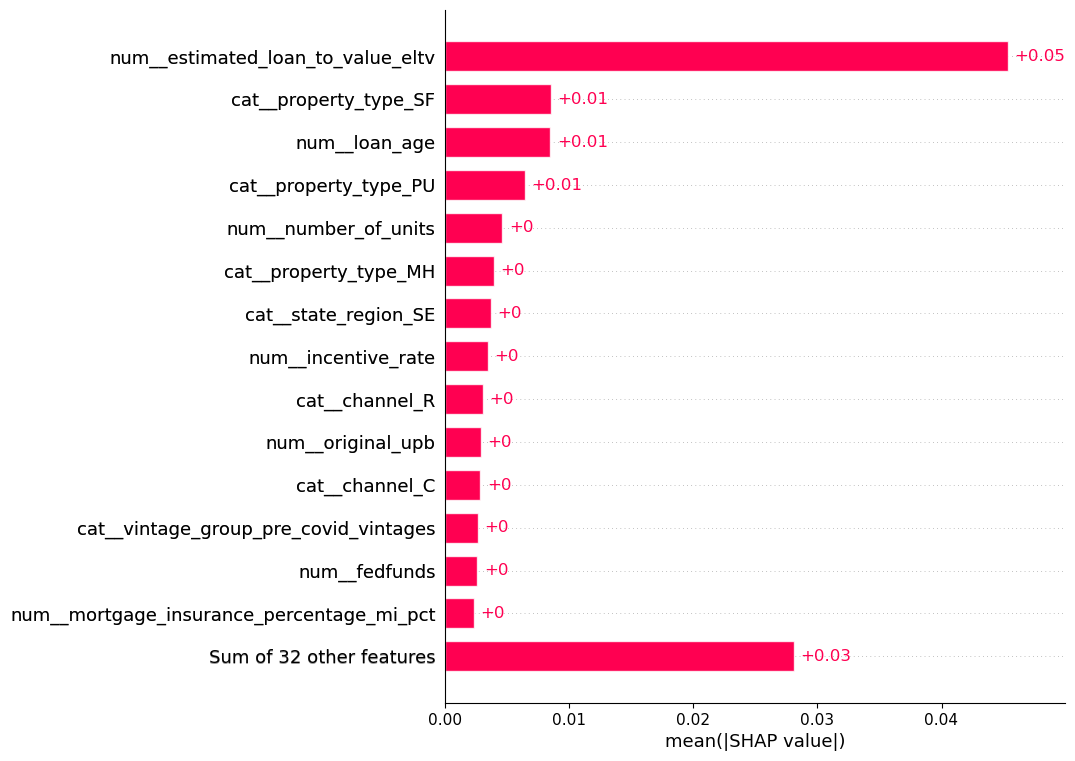

,model,train_rows,test_rows,n_features_raw,n_features_encoded,test_event_rate,roc_auc,pr_auc,log_loss,brier_score
0,default,1424249,360913,35,46,0.0008,0.8020,0.0133,0.0058,0.0008
1,prepay,1430718,354444,35,46,0.0108,0.9662,0.4357,0.0507,0.0111


In [6]:
from sklearn import neural_network
from torch import mode


BASELINE_EXCLUDE_COLS = {
    'loan_id',
    'rp_yyyymm',
    'first_payment_date',
    'maturity_date',
    'first_payment_date_dt',
    'maturity_date_dt',
    'postal_code',
    'msa_code',
    'seller_name',
    'servicer_name',
    'current_actual_upb',
    'year'
}

def coerce_numeric_like(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        series = df[col]
        if not (pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)):
            continue
        cleaned = series.astype('string').replace({'': pd.NA, '<NA>': pd.NA})
        converted = pd.to_numeric(cleaned, errors='coerce')
        if cleaned.notna().sum() == converted.notna().sum():
            df[col] = converted
        else:
            df[col] = cleaned
    return df

def prepare_baseline_frame(df: pd.DataFrame, target_col: str, already_engineered: bool = False,
                           feature_cols: list[str] | None = None):
    fe = df.copy() if already_engineered else feature_engineering(df)
    loan_ids = fe['loan_id'].copy()
    y = fe[target_col].astype(int).copy()
    X = fe.drop(columns=[target_col]).copy()

    drop_cols = [col for col in BASELINE_EXCLUDE_COLS if col in X.columns]
    X = X.drop(columns=drop_cols)

    X = coerce_numeric_like(X)

    if feature_cols is not None:
        missing_feature_cols = [col for col in feature_cols if col not in X.columns]
        if missing_feature_cols:
            raise KeyError(f"Requested feature_cols not found in baseline frame: {missing_feature_cols[:10]}")
        X = X.loc[:, feature_cols].copy()

    return X, y, loan_ids

def run_neural_network_model(df: pd.DataFrame, target_col: str, label: str,
                       test_size: float = 0.2, random_state: int = 42,
                       already_engineered: bool = False,
                       feature_cols: list[str] | None = None):
    X, y, loan_ids = prepare_baseline_frame(
        df,
        target_col,
        already_engineered=already_engineered,
        feature_cols=feature_cols,
    )

    loan_level_target = pd.DataFrame({
        'loan_id': loan_ids,
        target_col: y
    }).groupby('loan_id')[target_col].max()

    train_loans, test_loans = train_test_split(
        loan_level_target.index,
        test_size=test_size,
        random_state=random_state,
        stratify=loan_level_target.values,
    )

    train_mask = loan_ids.isin(train_loans).to_numpy()
    test_mask = loan_ids.isin(test_loans).to_numpy()

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]
    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), numeric_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
            ]), categorical_cols),
        ],
        remainder='drop',
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler', MaxAbsScaler()),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=(40,20,10),
            activation='relu',
            random_state=random_state,
            tol=1e-6,
       )),
    ])

    model.fit(X_train, y_train)

    # get the loss curve
    model_loss_curve = model.named_steps['classifier'].loss_curve_
    fig,axs = plt.subplots(figsize=(6,4))
    axs.plot(model_loss_curve)
    axs.set_title(f'{label} Loss Curve')
    axs.set_xlabel('Iteration')
    axs.set_ylabel('Loss')
    fig.tight_layout()
    fig.savefig(f'../figures/{label}_loss_curve.png')
    plt.show()

    y_score = model.predict_proba(X_test)[:, 1]
    y_score_clipped = np.clip(y_score, 1e-12, 1 - 1e-12)

    # use SHAP values to get feature importance
    # shap_pipeline = Pipeline([
    #     ('preprocessor', preprocessor),
    #     ('scaler', MaxAbsScaler()),
    # ])

    # Preprocess data for SHAP
    X_test_processed = model.named_steps['preprocessor'].transform(X_test)
    X_train_processed = model.named_steps['preprocessor'].transform(X_train)
    
    # Get proper feature names from preprocessor (includes one-hot encoded names)
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    
    # Scale the data
    scaler = model.named_steps['scaler']
    X_test_scaled = scaler.transform(X_test_processed)
    X_train_scaled = scaler.transform(X_train_processed)

    # Use SHAP with the classifier only
    explainer = shap.Explainer(model.named_steps['classifier'].predict_proba, X_train_scaled, feature_names=feature_names)

    with open(f'../data/{label}_explainer.pkl', 'wb') as f:
        explainer.save(f)

    shap_sample = shap.sample(X_test_scaled, 1000, random_state=random_state)
    shap_values = explainer(shap_sample)

    # summarize the effects of all the features
    #shap.plots.beeswarm(shap_values[..., 0])
    shap.plots.bar(shap_values[..., 1], max_display=15)

    return {
        'model': label,
        'train_rows': int(train_mask.sum()),
        'test_rows': int(test_mask.sum()),
        'n_features_raw': int(X.shape[1]),
        'n_features_encoded': int(len(feature_names)),
        'test_event_rate': float(y_test.mean()),
        'roc_auc': float(roc_auc_score(y_test, y_score)),
        'pr_auc': float(average_precision_score(y_test, y_score)),
        'log_loss': float(log_loss(y_test, y_score_clipped, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_test, y_score)),
    }


neural_network_results = pd.DataFrame([
    run_neural_network_model(default_fe, 'y_default', 'default', already_engineered=True),
    run_neural_network_model(prepay_fe, 'y_prepay', 'prepay', already_engineered=True),
]).round(4)

neural_network_results